----------------------------------------
Najlepsze alpha: 0.001
Najlepszy wynik CV (R²): 0.6115
----------------------------------------


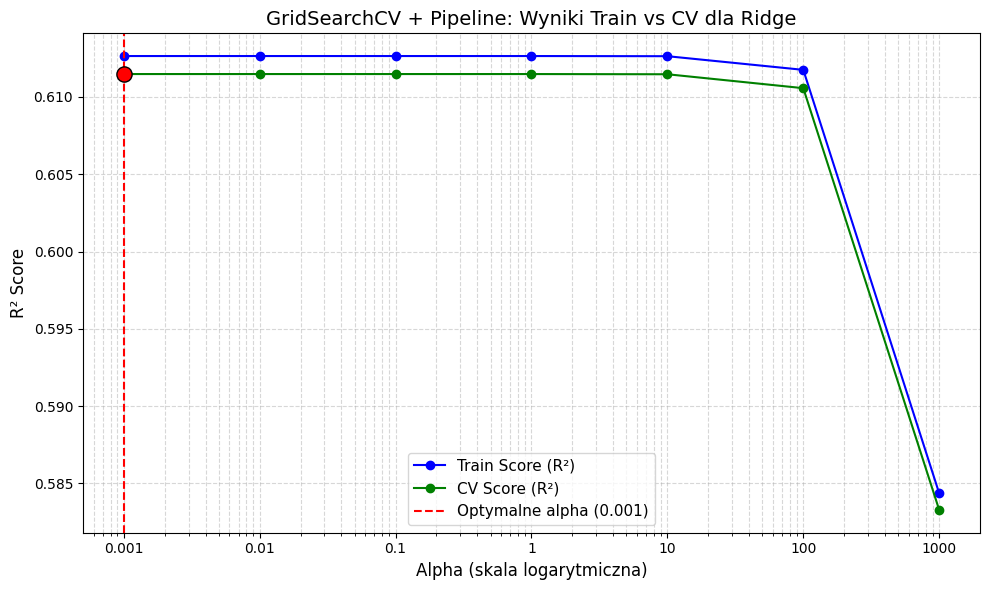

In [3]:
# Wczytaj California Housing. Użyj GridSearchCV do znalezienia optymalnego alpha dla
# Ridge spośród [0.001, 0.01, 0.1, 1, 10, 100, 1000]. Narysuj wykres train vs CV score.
# Dataset: sklearn.datasets.fetch_california_housing()
# Wymagania:
# GridSearchCV z cv=5, return_train_score=True
# Wykres: alpha (log scale) vs train/CV R²
# Zaznacz optymalne alpha
# Oczekiwany rezultat: Wykres + optymalne parametry

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Wczytywanie danych
california = fetch_california_housing()
X = california.data
y = california.target

# Podział danych
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

# Definicja pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Definicja siatki hiperparametrów ( Lista parametrów do przetestowania)
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
param_grid = {"ridge__alpha": alphas}


# GridSearchCV
grid_search = GridSearchCV(
pipeline,
param_grid,
cv=5, 
scoring='r2',
return_train_score=True,
n_jobs=1 # Używa wszystkich rdzeni CPU
)

# Trenujemy
grid_search.fit(X_train, y_train)

# 6. Wyciągnięcie wyników z GridSearchCV
results = grid_search.cv_results_
train_scores = results["mean_train_score"]
cv_scores = results["mean_test_score"]

# Pobieramy najlepszy parametr (zwróci np. {'ridge__alpha': 10})
best_params = grid_search.best_params_
best_alpha = best_params["ridge__alpha"]
best_score = grid_search.best_score_

# Wypisanie optymalnych parametrów w konsoli
print("-" * 40)
print(f"Najlepsze alpha: {best_alpha}")
print(f"Najlepszy wynik CV (R²): {best_score:.4f}")
print("-" * 40)

# 7. Generowanie wykresu: alpha (log scale) vs train/CV R²
plt.figure(figsize=(10, 6))

# Wykres linii dla wyników treningowych i walidacyjnych
plt.plot(alphas, train_scores, "o-", label="Train Score (R²)", color="blue")
plt.plot(alphas, cv_scores, "o-", label="CV Score (R²)", color="green")

# Zaznaczenie pionową linią optymalnego alpha
plt.axvline(
    x=best_alpha,
    linestyle="--",
    color="red",
    label=f"Optymalne alpha ({best_alpha})",
)

# Wyróżnienie punktu z najlepszym wynikiem
plt.scatter(
    [best_alpha],
    [best_score],
    color="red",
    edgecolor="black",
    s=120,
    zorder=5,
)

# Formatowanie osi i legendy
plt.xscale("log")  # Skala logarytmiczna dla osi X
plt.xlabel("Alpha (skala logarytmiczna)", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.title(
    "GridSearchCV + Pipeline: Wyniki Train vs CV dla Ridge", fontsize=14
)
plt.xticks(alphas, labels=[str(a) for a in alphas])
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=11)

# Wyświetlenie wykresu
plt.tight_layout()
plt.show()

| Dataset                     | Model      |   Optymalne Alpha | Optymalne L1 Ratio   |   Test R² | Niezerowe cechy   |
|:----------------------------|:-----------|------------------:|:---------------------|----------:|:------------------|
| California Housing (Sample) | Ridge      |          291.505  | Nie dotyczy          |    0.5455 | 8 / 8             |
| California Housing (Sample) | Lasso      |            0.0811 | Nie dotyczy          |    0.494  | 4 / 8             |
| California Housing (Sample) | ElasticNet |            0.2477 | 0.10                 |    0.5179 | 5 / 8             |
| Synthetic Regression        | Ridge      |            0.0001 | Nie dotyczy          |    0.9999 | 20 / 20           |
| Synthetic Regression        | Lasso      |            0.2057 | Nie dotyczy          |    0.9999 | 10 / 20           |
| Synthetic Regression        | ElasticNet |            0.0221 | 0.99                 |    0.9999 | 14 / 20           |


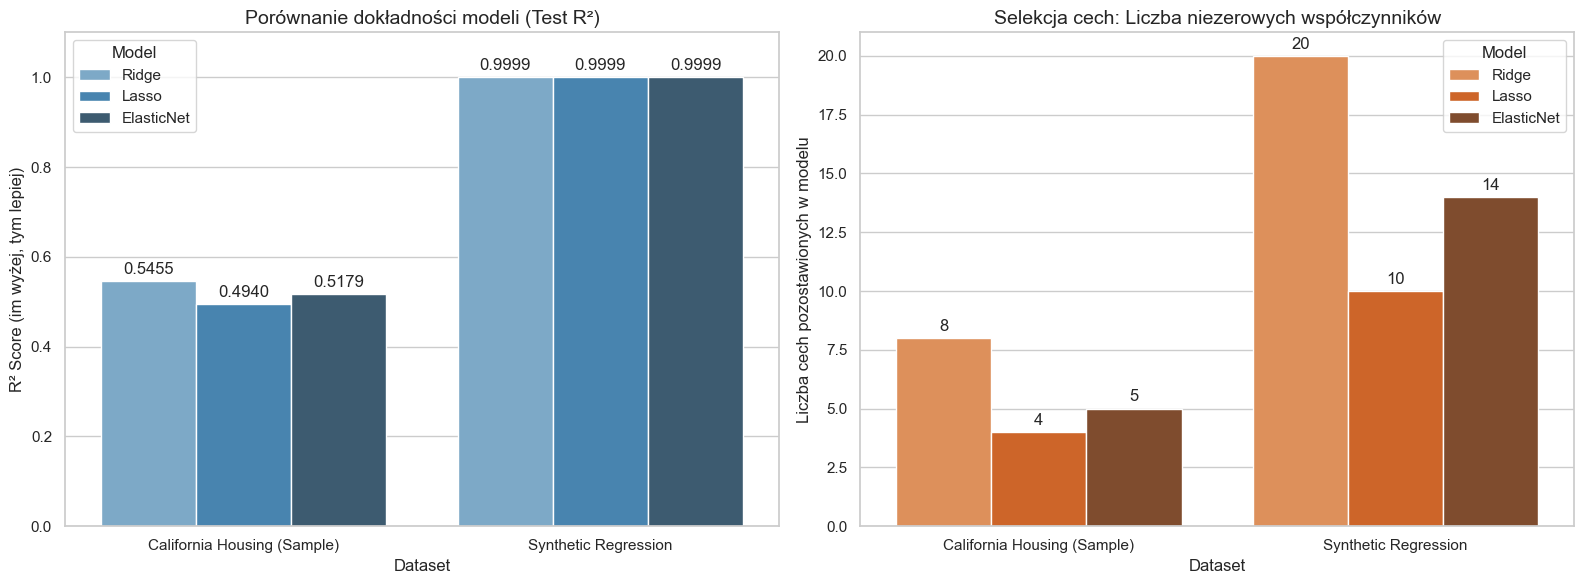

In [4]:
# Porównaj Ridge, Lasso i ElasticNet na dwóch datasetach: California Housing i Boston
# Housing (użyj make_regression jeśli Boston niedostępny). Dla każdego datasetu znajdź
# optymalne hiperparametry przez CV.
# Dataset: California Housing + make_regression(n_samples=500, n_features=20,
# n_informative=10)
# Wymagania:
# RidgeCV, LassoCV, ElasticNetCV
# Porównaj R² i liczbę niezerowych cech
# Który model najlepszy dla którego datasetu?
# Oczekiwany rezultat: Tabela porównawcza + wnioski

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definiujemy stałą losowości (by wyniki były zawsze takie same)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dataset: California Housing 
california = fetch_california_housing()
sample_idx = np.random.choice(len(california.data), size=2000, replace=False)
X_cal = california.data[sample_idx]
y_cal = california.target[sample_idx]

# Dataset: Boston Housing
X_reg, y_reg = make_regression(
    n_samples=500,
    n_features=20,
    n_informative=10,  # Tylko 10 cech z 20 ma znaczenie
    noise=1.0,
    random_state=RANDOM_STATE,
)

# /////////////////////////////////////////////////////////////////////////////

# Definiujemy przestrzenie przeszukiwań parametrów dla wbudowanego CV
alphas = np.logspace(-4, 4, 100)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

# Słownik ułatwiający iterację po obu zbiorach
datasets = {
    "California Housing (Sample)": (X_cal, y_cal),
    "Synthetic Regression": (X_reg, y_reg),
}

results = []

for dataset_name, (X, y) in datasets.items():
    # Podział danych (zgodnie z Twoim wymaganiem test_size=0.3)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_STATE
    )

    # Standaryzacja
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Definicja modeli CV (automatycznie dobierają najlepsze parametry przez 5-fold CV)
    models = {
        "Ridge": RidgeCV(alphas=alphas, cv=5),
        "Lasso": LassoCV(
            alphas=alphas, cv=5, max_iter=10000, random_state=RANDOM_STATE
        ),
        "ElasticNet": ElasticNetCV(
            alphas=alphas,
            l1_ratio=l1_ratios,
            cv=5,
            max_iter=10000,
            random_state=RANDOM_STATE,
        ),
    }

    # Trenowanie i zbieranie metryk
    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        # Obliczanie metryk
        r2 = r2_score(y_test, y_pred)
        # Zliczanie niezerowych wag z tolerancją na błędy zmiennoprzecinkowe
        non_zero_features = np.sum(np.abs(model.coef_) > 1e-5)

        # Pobieranie optymalnych parametrów z modelu
        opt_alpha = model.alpha_
        opt_l1 = (
            model.l1_ratio_ if hasattr(model, "l1_ratio_") else "Nie dotyczy"
        )

        results.append(
            {
                "Dataset": dataset_name,
                "Model": model_name,
                "Optymalne Alpha": f"{opt_alpha:.4f}",
                "Optymalne L1 Ratio": (
                    f"{opt_l1:.2f}" if isinstance(opt_l1, float) else opt_l1
                ),
                "Test R²": f"{r2:.4f}",
                "Niezerowe cechy": f"{non_zero_features} / {X.shape[1]}",
            }
        )

# Zamiana wyników na DataFrame i wyświetlenie w formie tabeli
df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False))


import matplotlib.pyplot as plt
import seaborn as sns

# Przygotowanie danych do wykresu (konwertujemy metryki tekstowe na liczbowe)
df_plot = df_results.copy()
df_plot["Test R²"] = df_plot["Test R²"].astype(float)
# Wyciągamy pierwszą liczbę z formatu "X / Y" (czyli liczbę niezerowych cech)
df_plot["Liczba niezerowych cech"] = (
    df_plot["Niezerowe cechy"].str.split(" / ").str[0].astype(int)
)

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wykres 1: Porównanie R² Score
sns.barplot(
    x="Dataset",
    y="Test R²",
    hue="Model",
    data=df_plot,
    ax=axes[0],
    palette="Blues_d",
)
axes[0].set_title("Porównanie dokładności modeli (Test R²)", fontsize=14)
axes[0].set_ylabel("R² Score (im wyżej, tym lepiej)", fontsize=12)
axes[0].set_xlabel("Dataset", fontsize=12)
axes[0].set_ylim(0, 1.1)  # Skala od 0 do 1.1, żeby słupki nie dotykały sufitu

# Dodanie wartości liczbowych nad słupkami R²
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.4f", padding=3)

# Wykres 2: Porównanie liczby zachowanych cech
sns.barplot(
    x="Dataset",
    y="Liczba niezerowych cech",
    hue="Model",
    data=df_plot,
    ax=axes[1],
    palette="Oranges_d",
)
axes[1].set_title(
    "Selekcja cech: Liczba niezerowych współczynników", fontsize=14
)
axes[1].set_ylabel("Liczba cech pozostawionych w modelu", fontsize=12)
axes[1].set_xlabel("Dataset", fontsize=12)

# Dodanie wartości liczbowych nad słupkami cech
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3)

# Wyświetlenie wykresów
plt.tight_layout()
plt.show()